# Klasifikasi Batik - Ekstraksi Fitur MobileNetV2 Saja

Notebook ini merupakan bagian dari *Ablation Study* untuk mengevaluasi performa model klasifikasi jika HANYA menggunakan fitur visual dari Deep Learning (MobileNetV2) tanpa fitur tekstur statistik.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import seaborn as sns


In [2]:
TRAIN_DIR = 'dataset/train'
TEST_DIR = 'dataset/test'
IMG_SIZE = (224, 224)

print("Loading MobileNetV2...")
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return final_img

def apply_zero_padding(img, target_size=(224, 224)):
    old_size = img.shape[:2]
    ratio = min(target_size[0]/old_size[0], target_size[1]/old_size[1])
    new_size = tuple([int(x*ratio) for x in old_size])
    
    img_resized = cv2.resize(img, (new_size[1], new_size[0]))
    
    delta_w = target_size[1] - new_size[1]
    delta_h = target_size[0] - new_size[0]
    top, bottom = delta_h//2, delta_h-(delta_h//2)
    left, right = delta_w//2, delta_w-(delta_w//2)
    
    color = [0, 0, 0]
    new_img = cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return new_img

def extract_cnn_features(img, model):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_padded = apply_zero_padding(img_rgb, target_size=IMG_SIZE)
    
    img_array = img_to_array(img_padded)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    features = model.predict(img_array, verbose=0)
    return features.flatten()


Loading MobileNetV2...




In [3]:
def process_dataset(directory, cnn_model, augment_rotation=False):
    features = []
    labels = []
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    
    for class_name in tqdm(classes, desc=f"Processing {directory}"):
        class_dir = os.path.join(directory, class_name)
        for img_name in os.listdir(class_dir):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            img_clahe = apply_clahe(img)
            rotations = [None]
            if augment_rotation:
                rotations.extend([cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE])
                
            for rot in rotations:
                try:
                    img_processed = cv2.rotate(img_clahe, rot) if rot is not None else img_clahe
                    cnn_feats = extract_cnn_features(img_processed, cnn_model)
                    features.append(cnn_feats)
                    labels.append(class_name)
                except Exception as e:
                    pass
    return np.array(features), np.array(labels)

X_train, y_train_raw = process_dataset(TRAIN_DIR, base_model, augment_rotation=True)
X_test, y_test_raw = process_dataset(TEST_DIR, base_model, augment_rotation=False)


Processing dataset/test: 100%|██████████| 20/20 [00:34<00:00,  1.71s/it]


In [4]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensi fitur CNN sebelum PCA: {X_train_scaled.shape[1]}")
print(f"Dimensi fitur CNN setelah PCA: {X_train_pca.shape[1]}")


Dimensi fitur CNN sebelum PCA: 1280
Dimensi fitur CNN setelah PCA: 674


Melatih model SVM dengan fitur MobileNetV2 saja...
Akurasi: 95.94%
Waktu Eksekusi: 3.83 detik

--- Classification Report (MobileNetV2 Only) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       1.00      0.88      0.93        16
               Bali_Barong       1.00      1.00      1.00        16
                Bali_Merak       1.00      1.00      1.00        16
           DKI_Ondel_Ondel       0.87      0.81      0.84        16
     JawaBarat_Megamendung       1.00      1.00      1.00        16
           JawaTimur_Pring       1.00      0.94      0.97        16
          Kalimantan_Dayak       1.00      1.00      1.00        16
             Lampung_Gajah       0.89      1.00      0.94        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       1.00      1.00      1.00        16
               NTB_Lumbung       1.00      0.88      0.93        16
               Papua_Asmat       1.00  

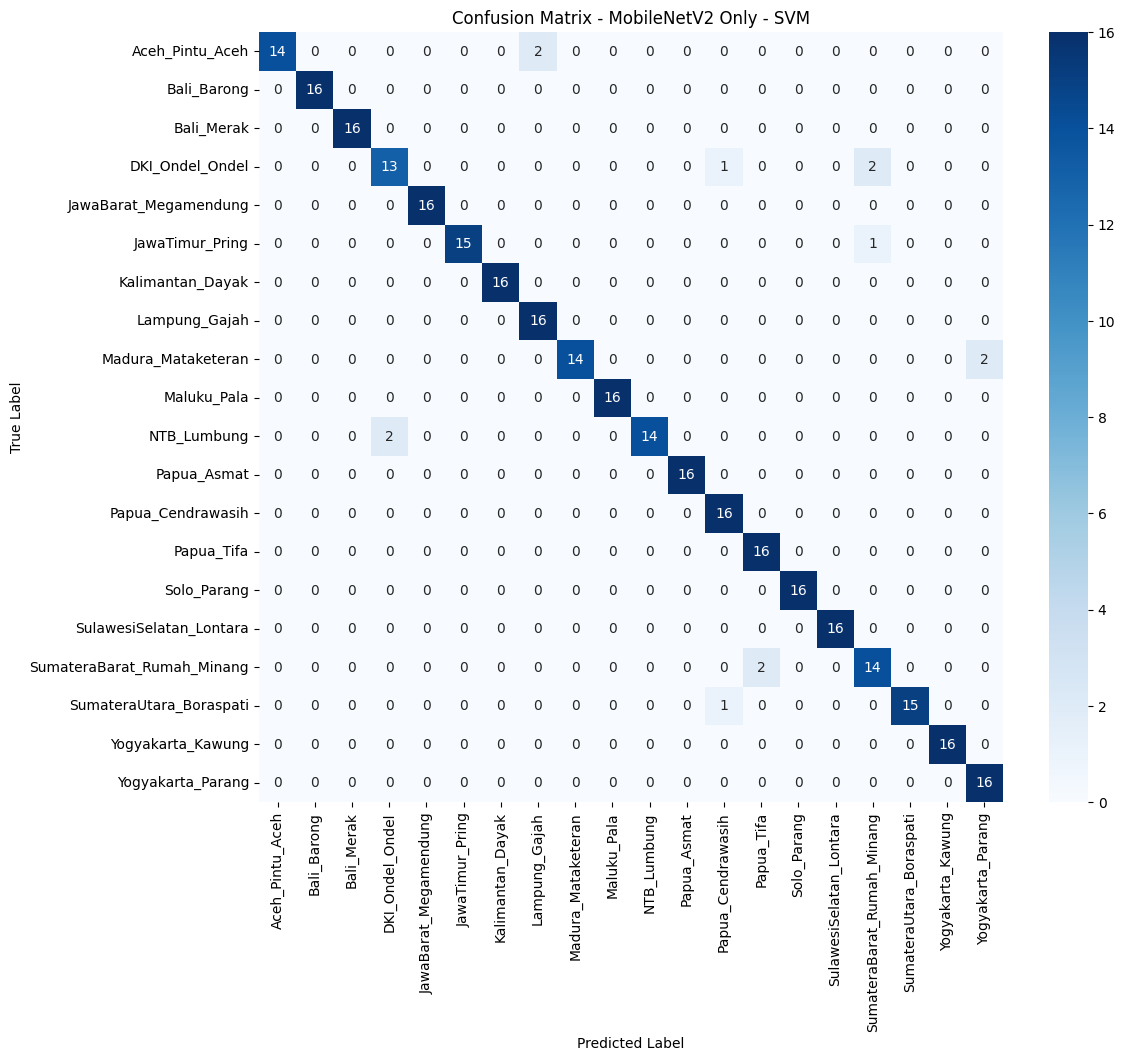

In [6]:
print("Melatih model SVM dengan fitur MobileNetV2 saja...")
model = SVC(C=10, kernel='rbf', random_state=42)

start_time = time.time()
model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)
end_time = time.time()

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc * 100:.2f}%")
print(f"Waktu Eksekusi: {end_time - start_time:.2f} detik")

print("\n--- Classification Report (MobileNetV2 Only) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - MobileNetV2 Only - SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.show()
